# ex-2 v2 — mono, composed on `fl_plot` (modern API remake)

The ex-2 v2 figure set rebuilt entirely from `fl_plot` marks — no fl_graphics helpers, no
local plotting functions. Mono treatment throughout (gray boxes, factor identity via hatching, bare
measured dots), with a **component-colored** section at the end (box color = quantity,
matching the band fills). Data loads from the shared `ex2v2_df_{p,n}.parquet` cache; this
notebook is composition-only — regenerate the cache with `ex-2_heavy_tail_v2` (root) or
its mono duplicate if missing. Figures → `nb_outputs/mono-ex2v2-flplot/`.

| legacy figure | composition here |
|---|---|
| five-row decomposition | `Row(BandStack)` + four `Row(BoxDist)` |
| component two-rows (1–4) | `Row([Band, MeanCI])` + `Row(BoxDist)` |
| rotation (Q1–Q3 view) | `Row([QuantileBand, MeanCI])` + `Row(BoxDist)` |
| in-subspace rotation dist | `Row([BoxDist, RefOverlay])` |

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "fl_plot.py").exists():
    REPO_ROOT = REPO_ROOT.parent          # notebook lives in mono/
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import (grid, Row, BandStack, Band, MeanCI, QuantileBand, BoxDist,
                     RefOverlay, Theme, THEME)

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "mono" / "nb_outputs" / "ex2v2-flplot"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6, factor_cmaps=("Greys",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


_pq_p, _pq_n = DATA_DIR / "ex2v2_df_p.parquet", DATA_DIR / "ex2v2_df_n.parquet"
if not (_pq_p.exists() and _pq_n.exists()):
    raise RuntimeError("ex2v2 sweep cache missing — run ex-2_heavy_tail_v2 (root) or "
                       "mono/ex-2_heavy_tail_v2_mono first to regenerate it.")


def derive(df):
    """Theory limits + pathwise differences, from the recorded columns."""
    oos = df["measured_out_of_subspace"]
    return df.assign(
        theory_insub=df["rhs"] - df["floor"],
        gap=df["rhs"] - df["sin2_j"],
        diff_oos=df["floor"] - oos,
        diff_insub=(df["rhs"] - df["floor"]) - df["measured_in_subspace"],
        sin2_in=(df["sin2_j"] - oos) / (1.0 - oos),
    )


df_p, df_n = derive(pd.read_parquet(_pq_p)), derive(pd.read_parquet(_pq_n))
_SWEEPS = [(df_p, "p", "growing p, fixed n=63"), (df_n, "n", "growing n, fixed p=3000")]

# eq.(18) sanity, per replicate
for d, key, lab in _SWEEPS:
    recon = d["measured_out_of_subspace"] + d["measured_in_subspace"]
    print(f"{lab}: max |sin2_j − (oos + insub)| = {(d['sin2_j'] - recon).abs().max():.2e}")

growing p, fixed n=63: max |sin2_j − (oos + insub)| = 0.00e+00
growing n, fixed p=3000: max |sin2_j − (oos + insub)| = 0.00e+00


## Five-row decomposition

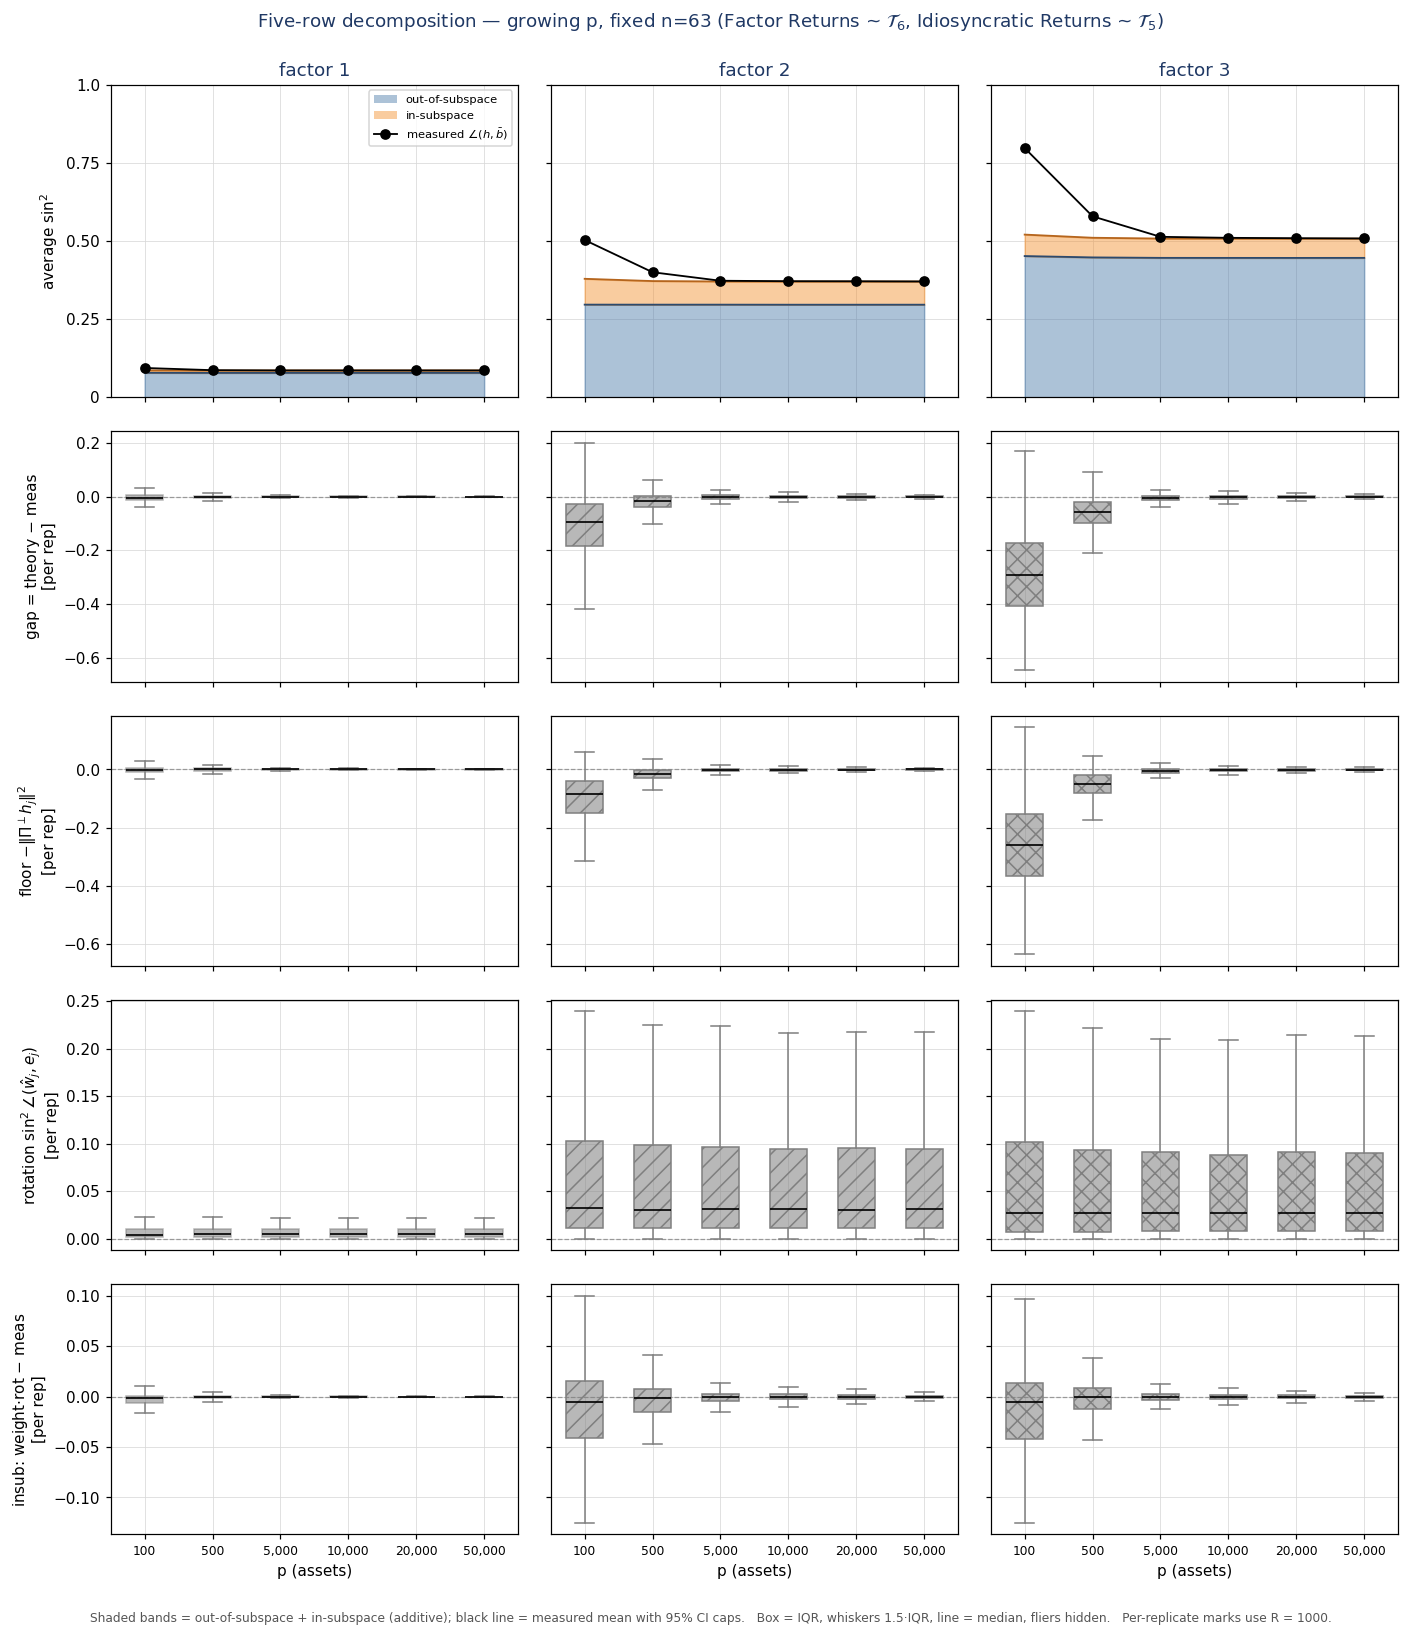

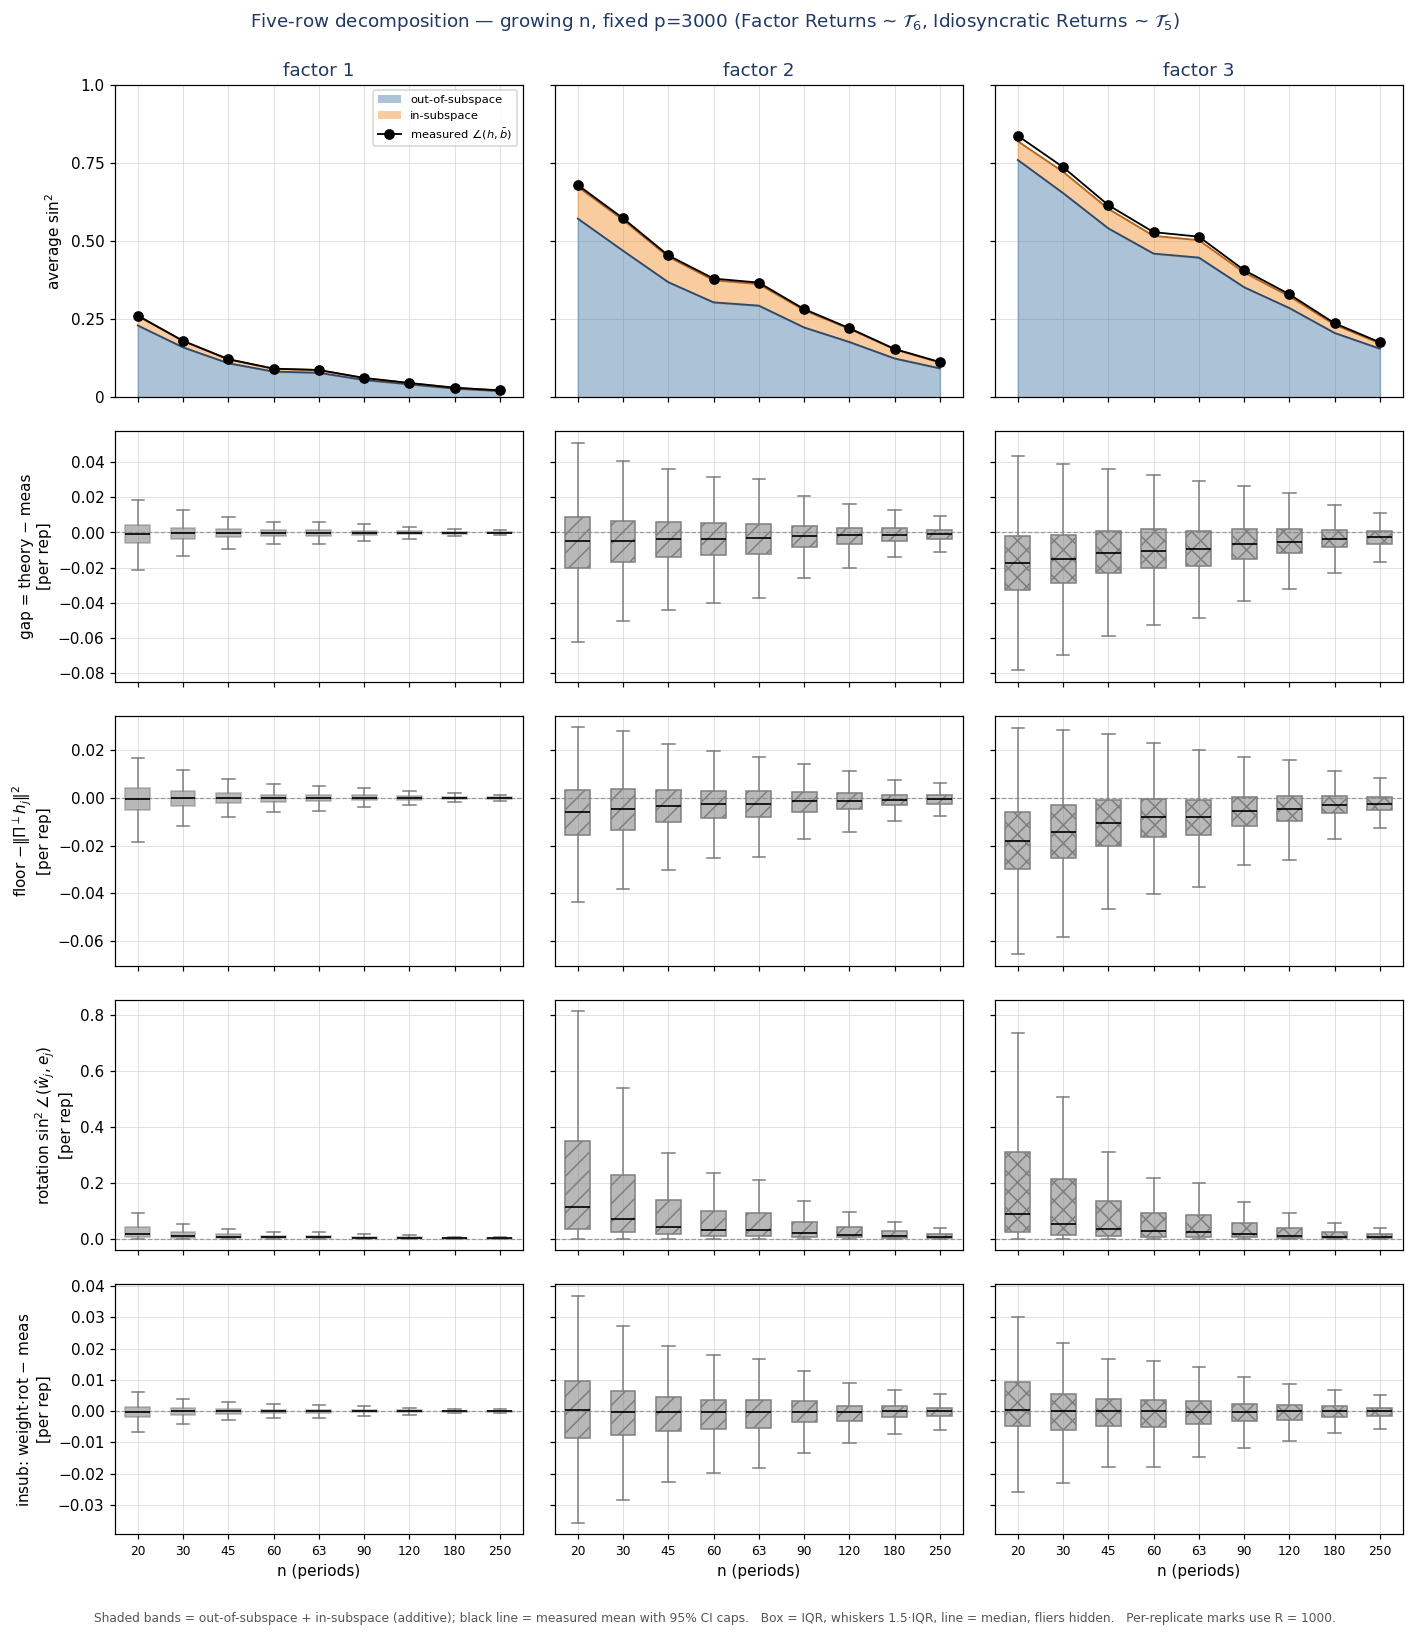

In [2]:
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="gap = theory − meas\n[per rep]"),
              Row(BoxDist("diff_oos"),
                  ylabel=r"floor $- \Vert\Pi^{\perp}h_j\Vert^2$" + "\n[per rep]"),
              Row(BoxDist("rotation"),
                  ylabel=r"rotation $\sin^2\angle(\hat w_j, e_j)$" + "\n[per rep]"),
              Row(BoxDist("diff_insub"),
                  ylabel=r"insub: weight$\cdot$rot $-$ meas" + "\n[per rep]")],
        theme=MONO_THEME,
        suptitle=f"Five-row decomposition — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_fiverow_{key}"))
    show(fig)

## Broken-out component figures

Total, out-of-subspace, rotation, in-subspace — each a band/limit top row over a pathwise
boxplot row, per sweep.

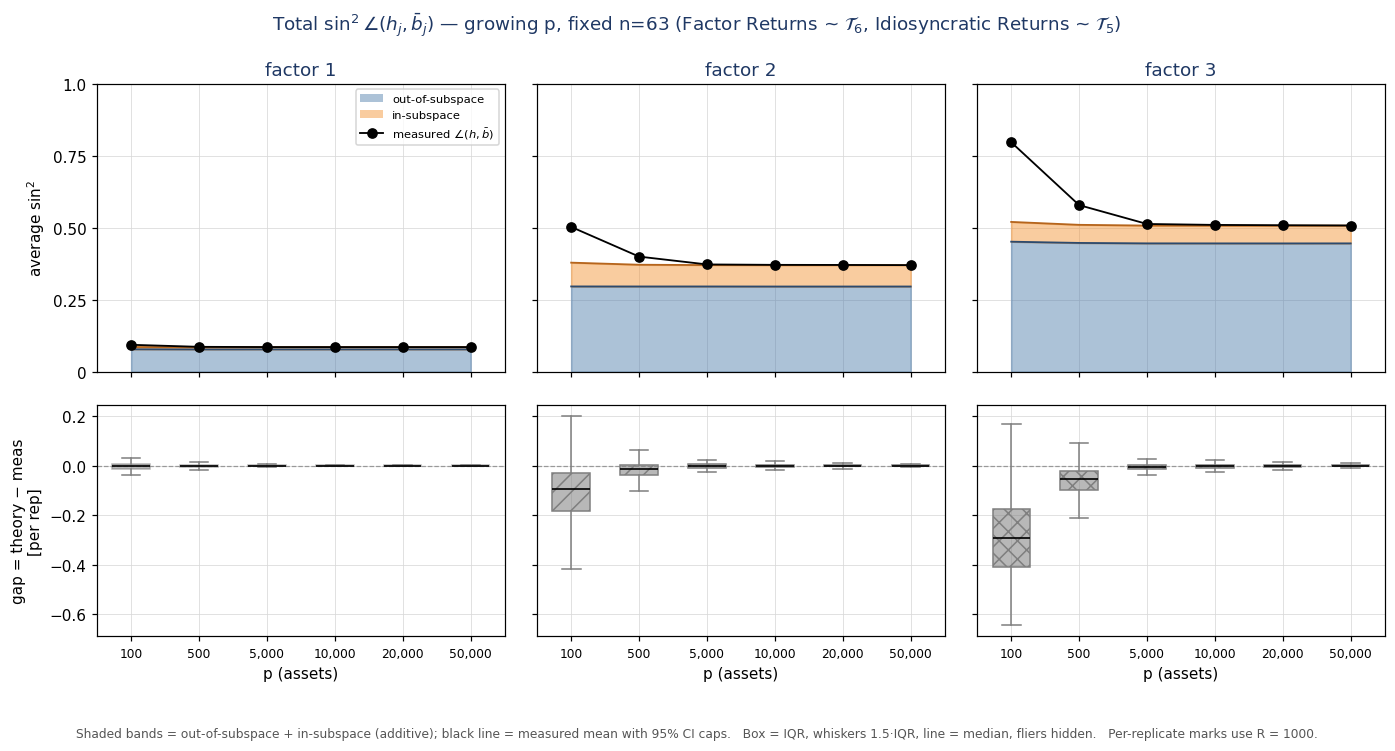

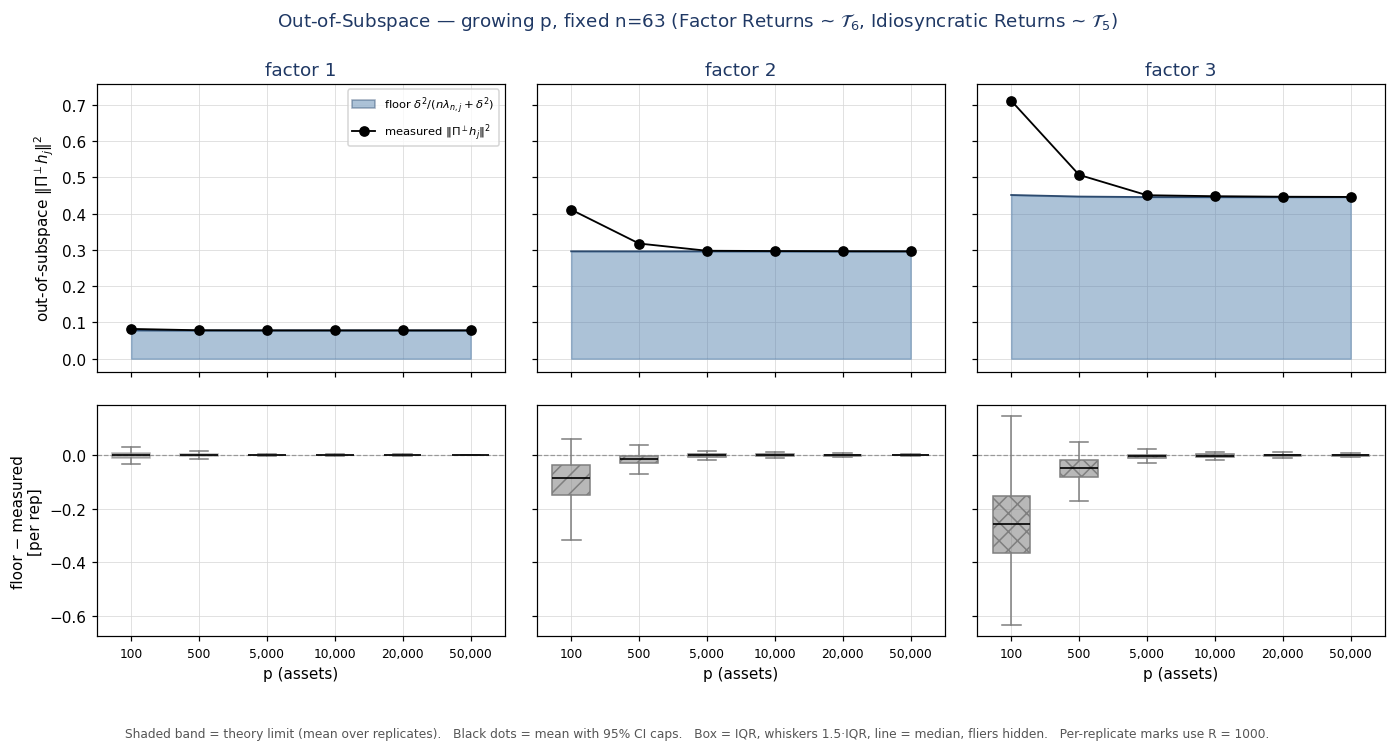

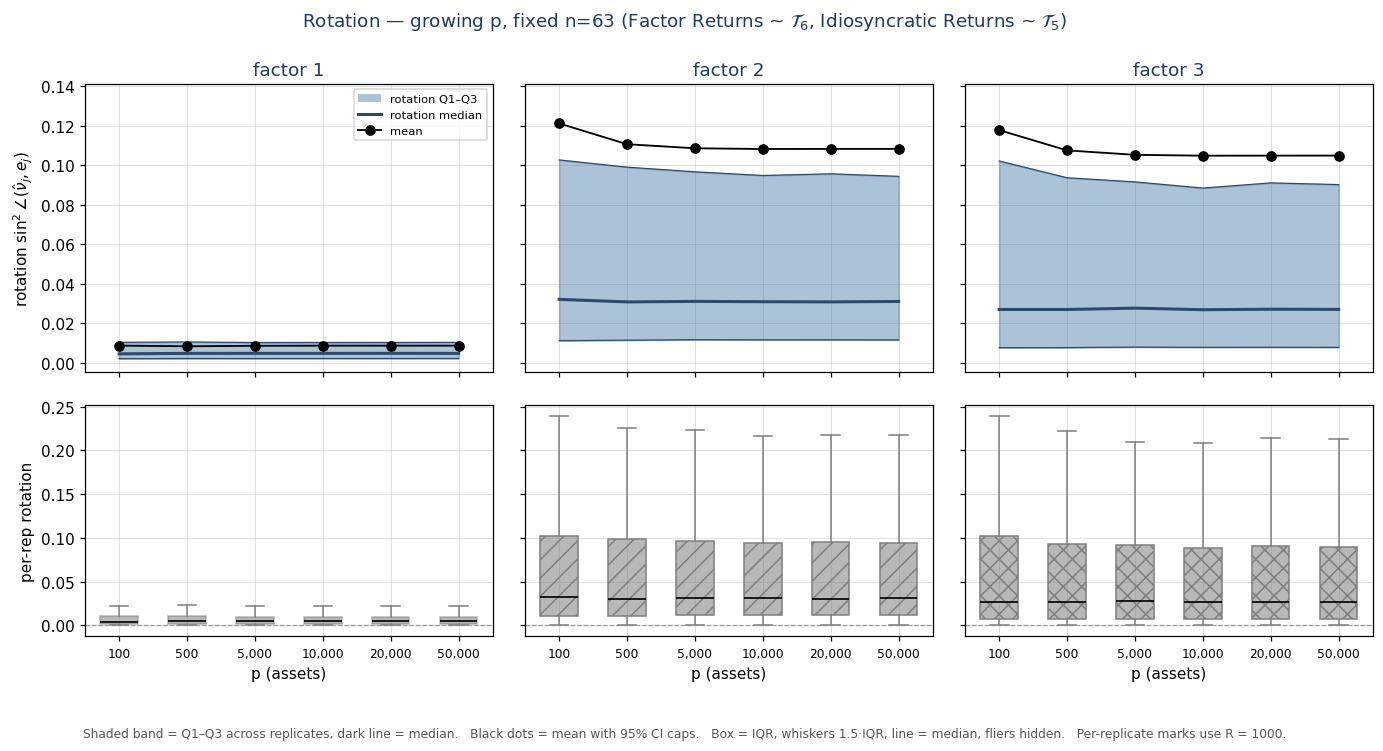

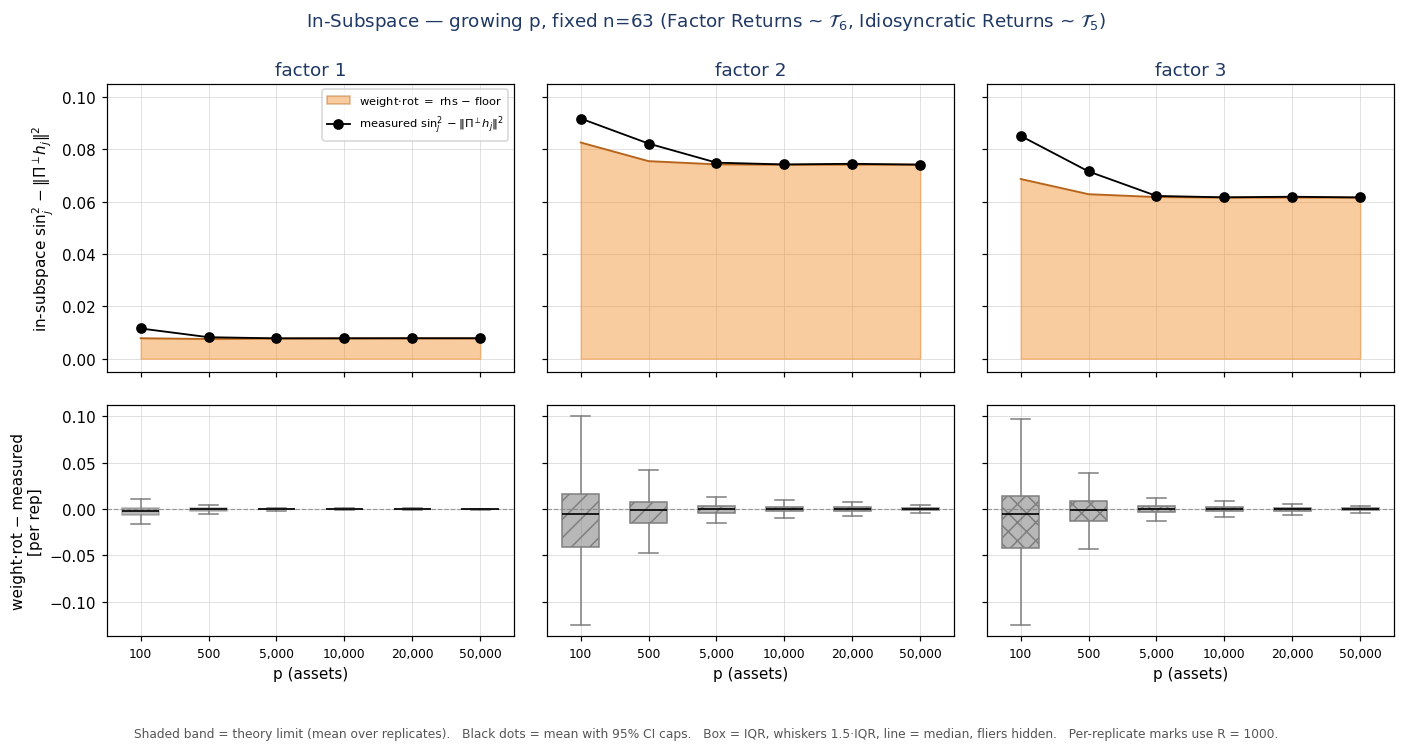

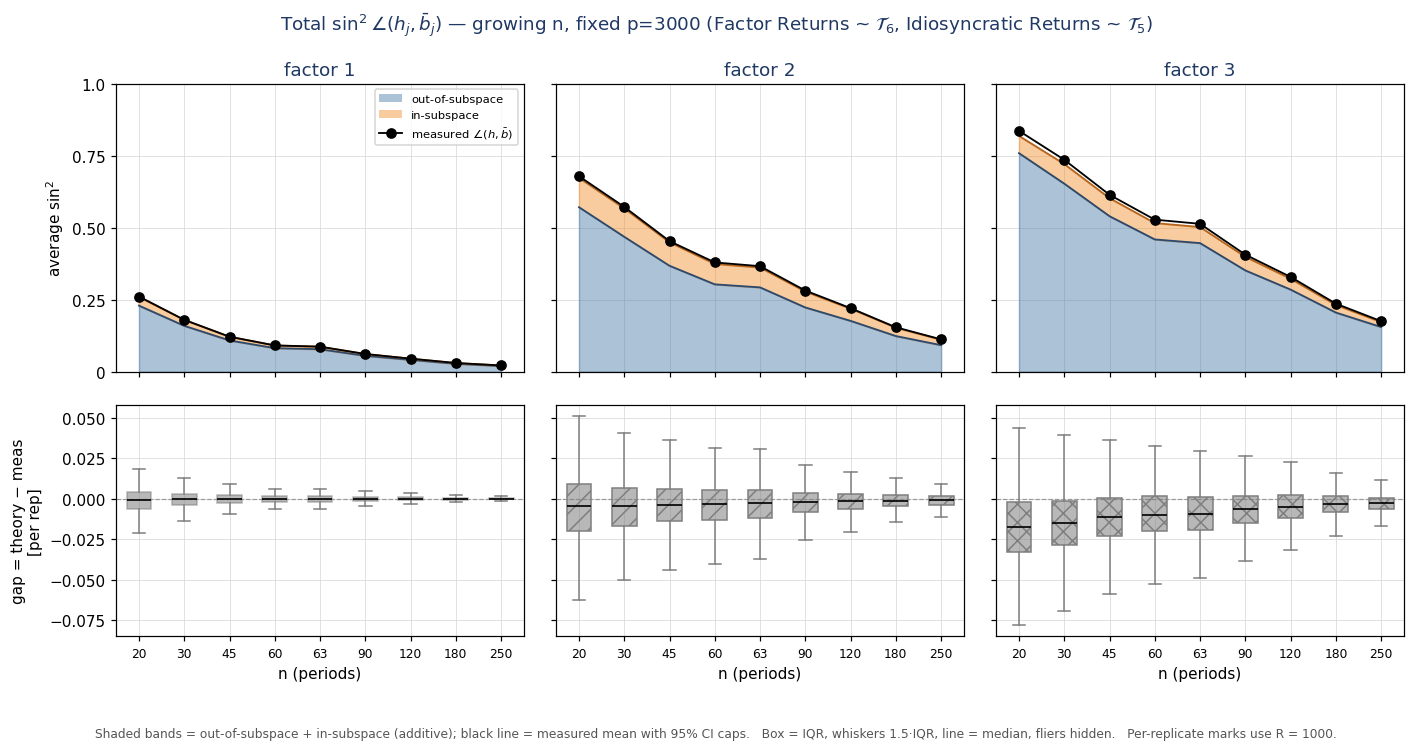

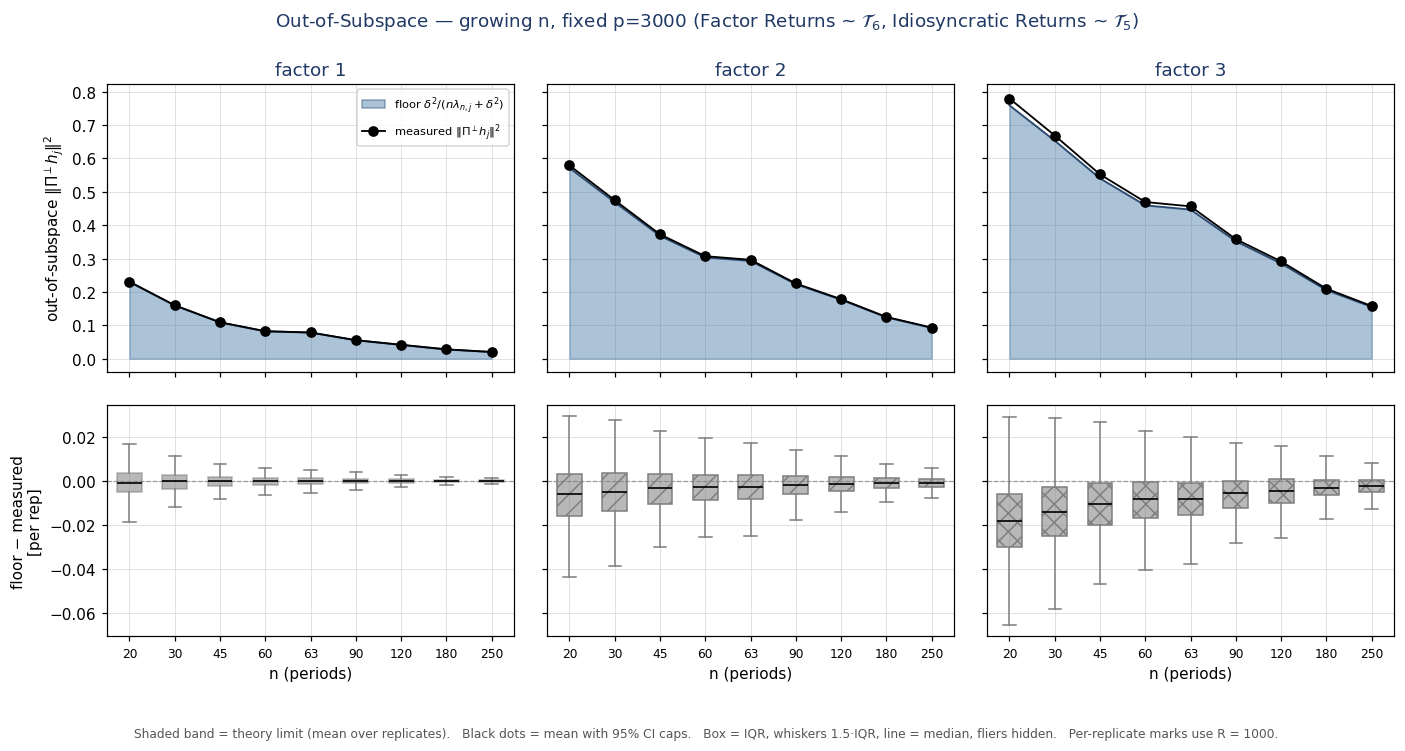

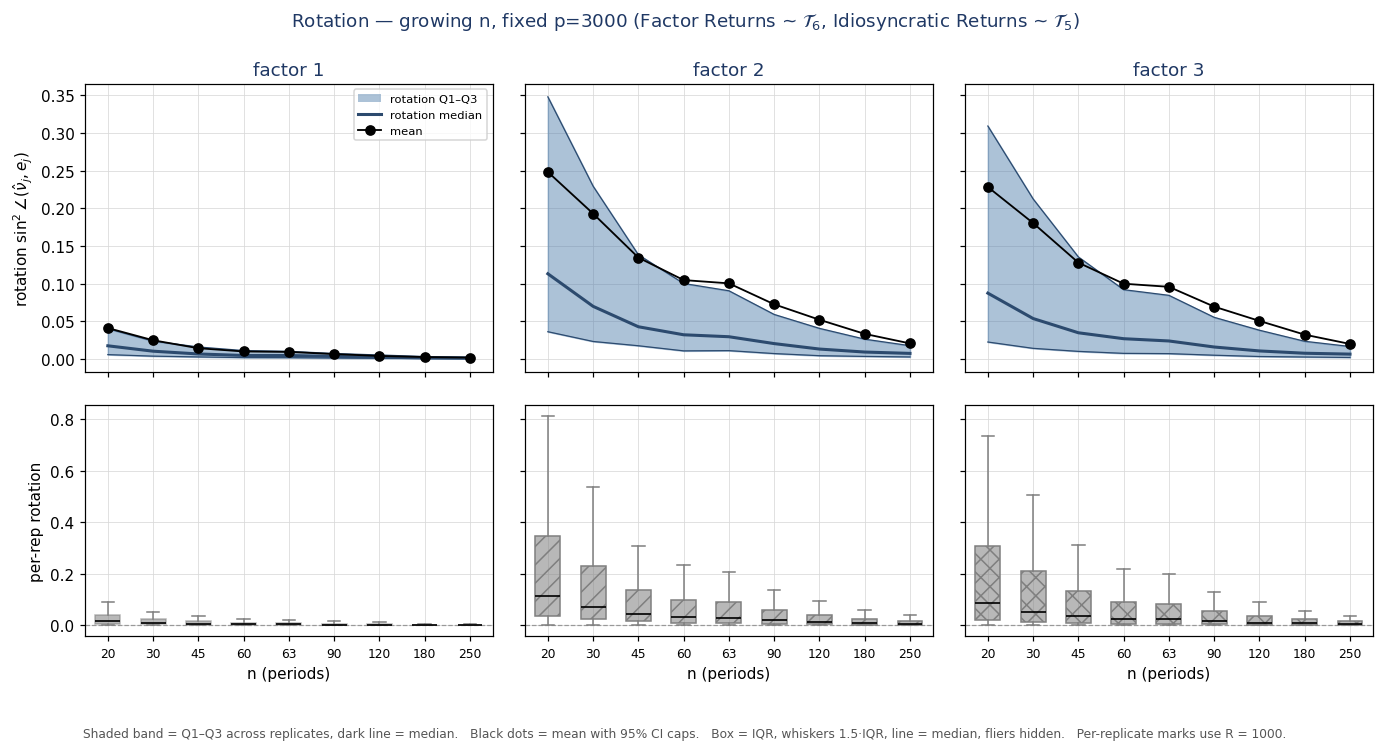

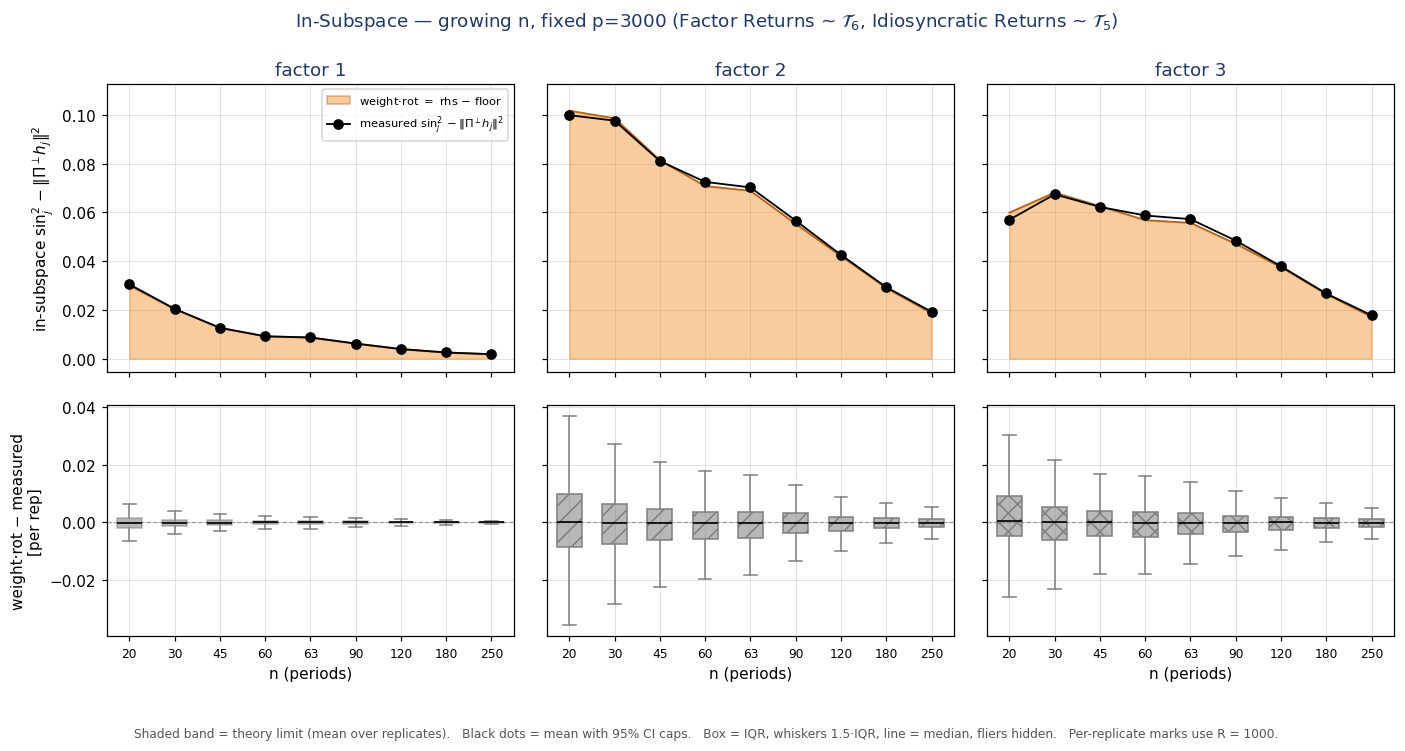

In [3]:
for d, key, lab in _SWEEPS:
    # 1 — total
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="gap = theory − meas\n[per rep]")],
        theme=MONO_THEME,
        suptitle=rf"Total $\sin^2\angle(h_j,\bar b_j)$ — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp1_total_{key}"))
    show(fig)
    # 2 — out-of-subspace
    fig, _ = grid(d, key,
        rows=[Row([Band("floor", label=r"floor $\delta^2/(n\lambda_{n,j}+\delta^2)$"),
                   MeanCI("measured_out_of_subspace",
                          label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                  ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_oos"), ylabel="floor − measured\n[per rep]")],
        theme=MONO_THEME,
        suptitle=rf"Out-of-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp2_oos_{key}"))
    show(fig)
    # 3 — rotation (a measured level: Q1–Q3 distribution view, no theory pair)
    fig, _ = grid(d, key,
        rows=[Row([QuantileBand("rotation", label="rotation"),
                   MeanCI("rotation", label="mean")],
                  ylabel=r"rotation $\sin^2\angle(\hat\nu_j, e_j)$", height=1.0),
              Row(BoxDist("rotation"), ylabel="per-rep rotation")],
        theme=MONO_THEME,
        suptitle=rf"Rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp3_rotation_{key}"))
    show(fig)
    # 4 — in-subspace
    fig, _ = grid(d, key,
        rows=[Row([Band("theory_insub", label=r"weight$\cdot$rot $=$ rhs $-$ floor",
                        fill=THEME.insub_fill, line=THEME.insub_line),
                   MeanCI("measured_in_subspace",
                          label=r"measured $\sin^2_j - \Vert\Pi^{\perp}h_j\Vert^2$")],
                  ylabel=r"in-subspace $\sin^2_j-\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_insub"), ylabel="weight·rot − measured\n[per rep]")],
        theme=MONO_THEME,
        suptitle=rf"In-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp4_insub_{key}"))
    show(fig)

## In-subspace rotation distribution (limit overlaid)

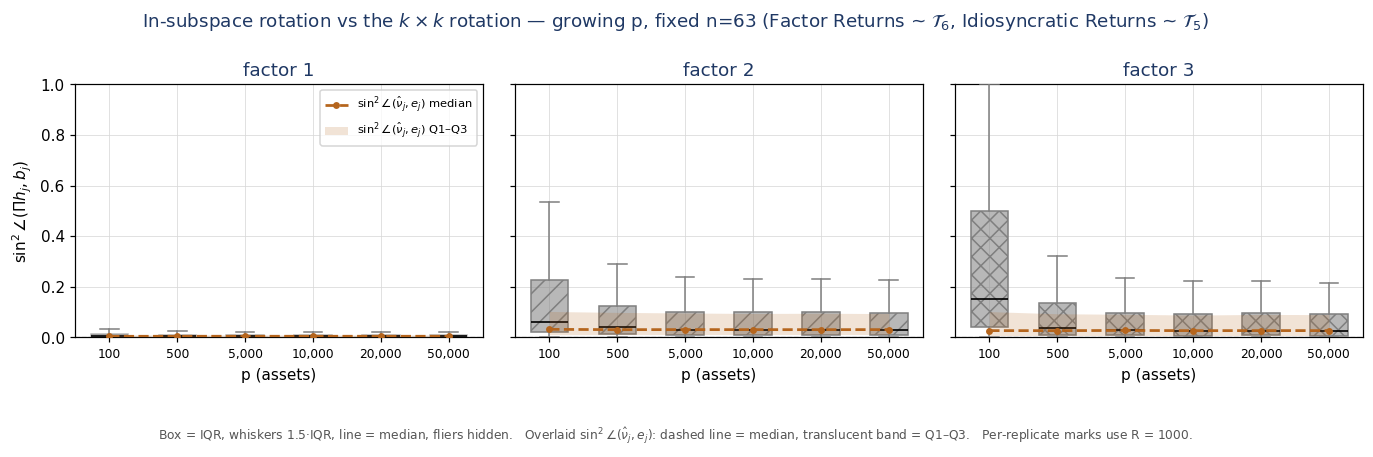

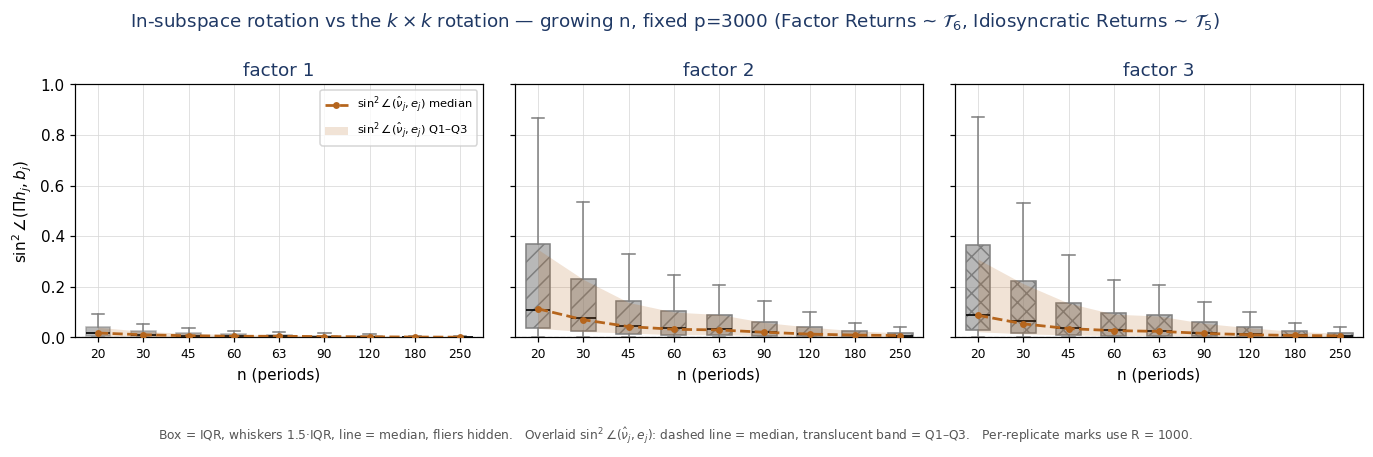

In [4]:
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row([BoxDist("sin2_in"),
                   RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                  ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
        sharey=True, theme=MONO_THEME,
        suptitle=f"In-subspace rotation vs the $k\\times k$ rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_insub_rotation_{key}"))
    show(fig)

---
## Component-colored versions

Box color = quantity, matching the band fills: total gray, out-of-subspace blue,
rotation green, in-subspace orange.

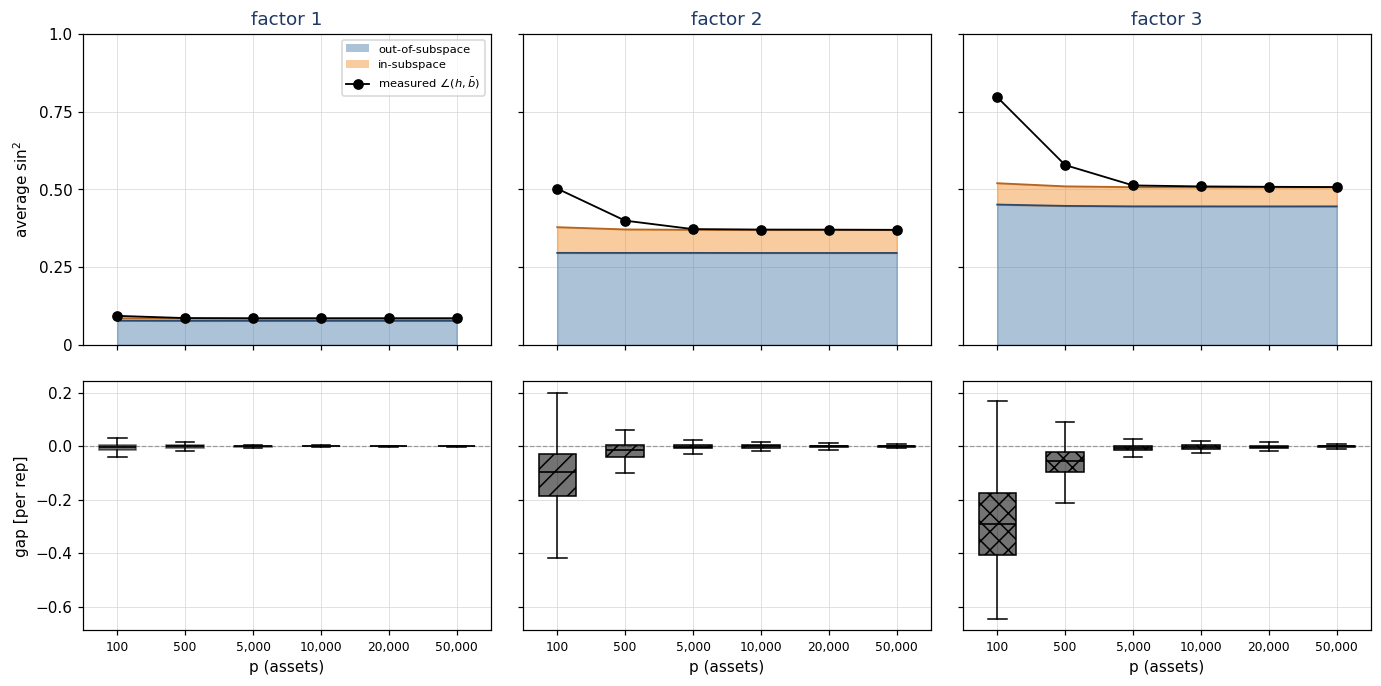

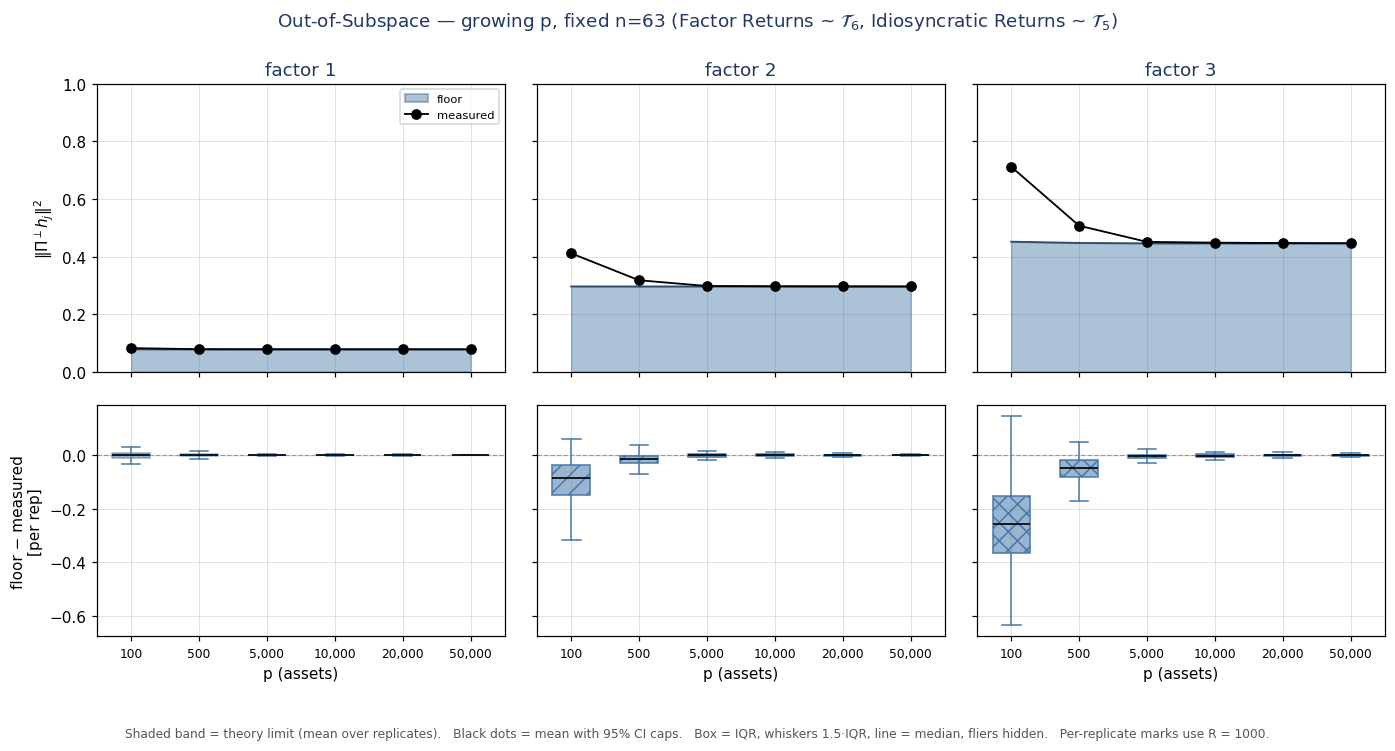

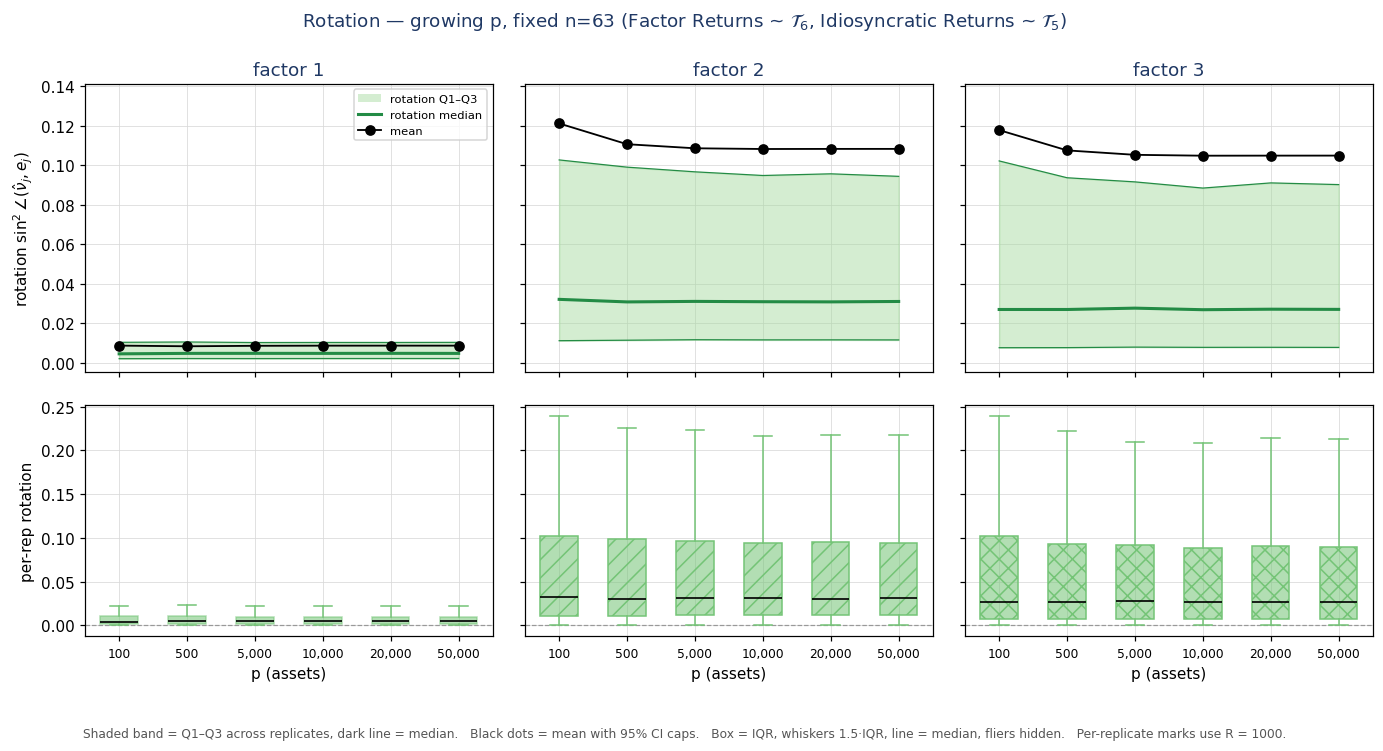

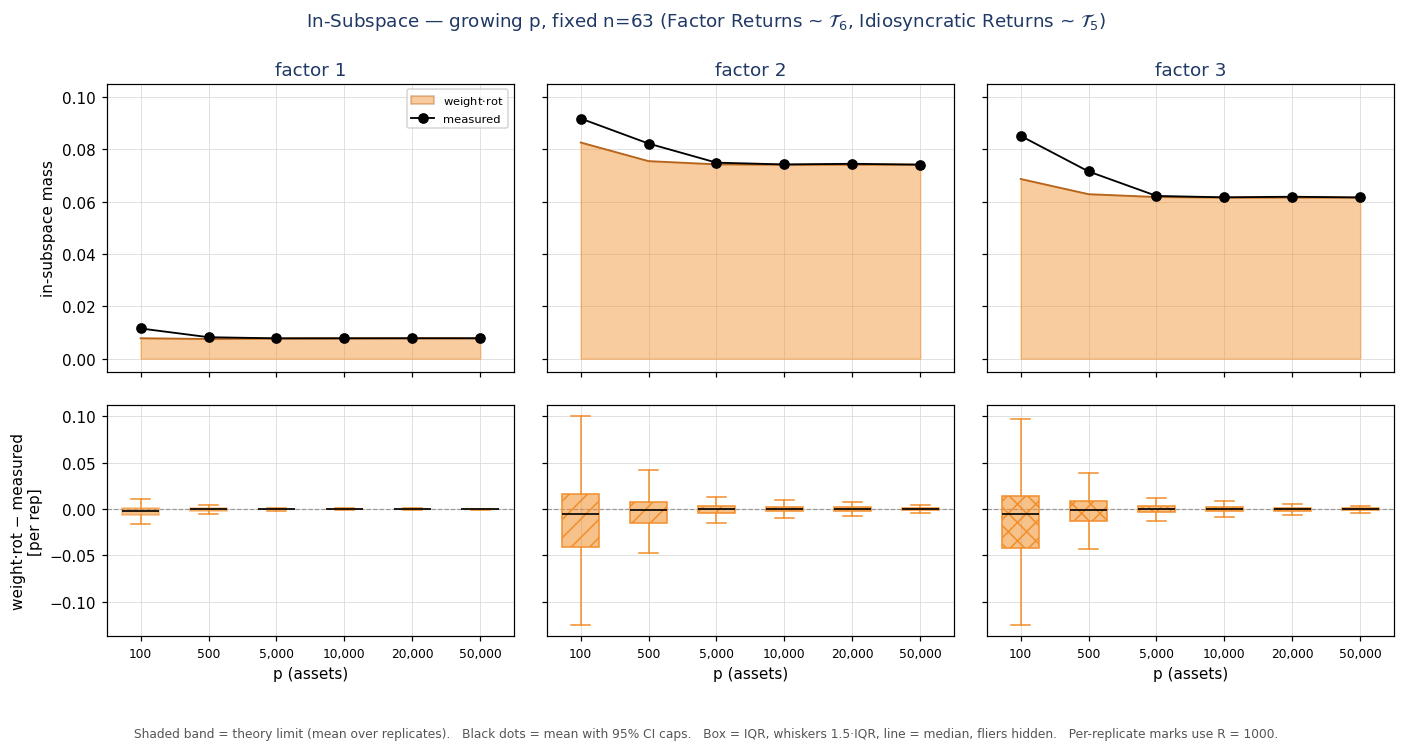

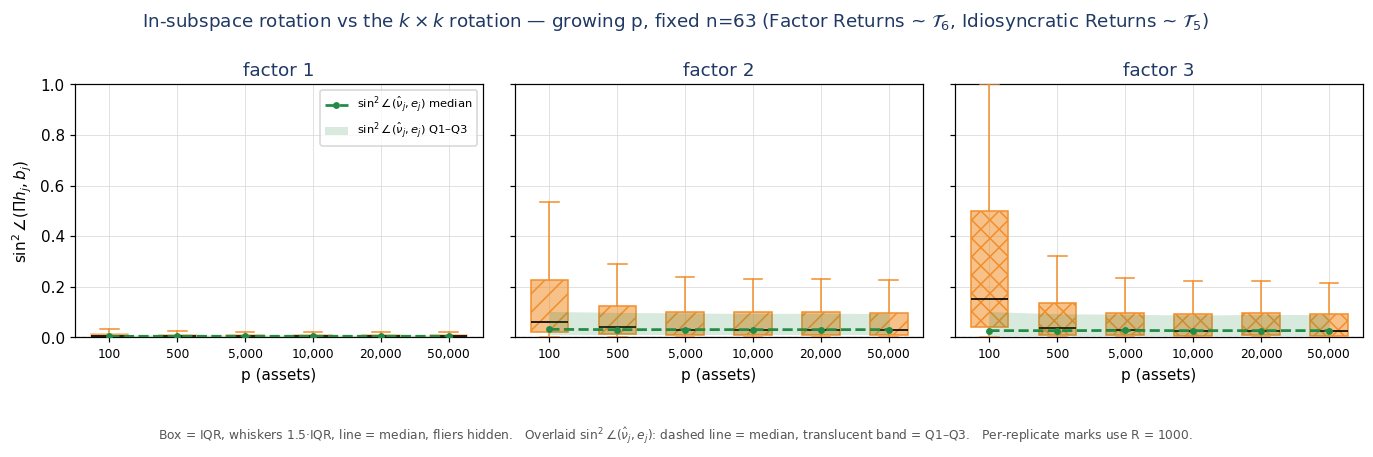

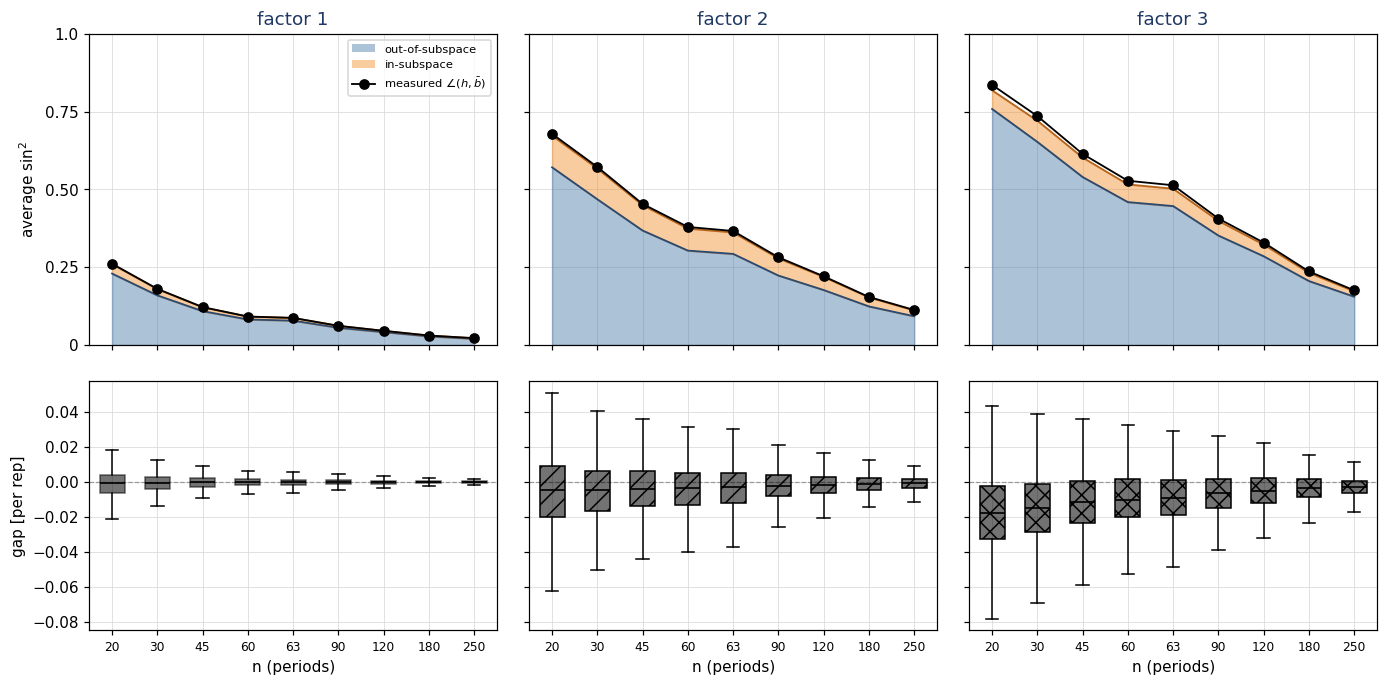

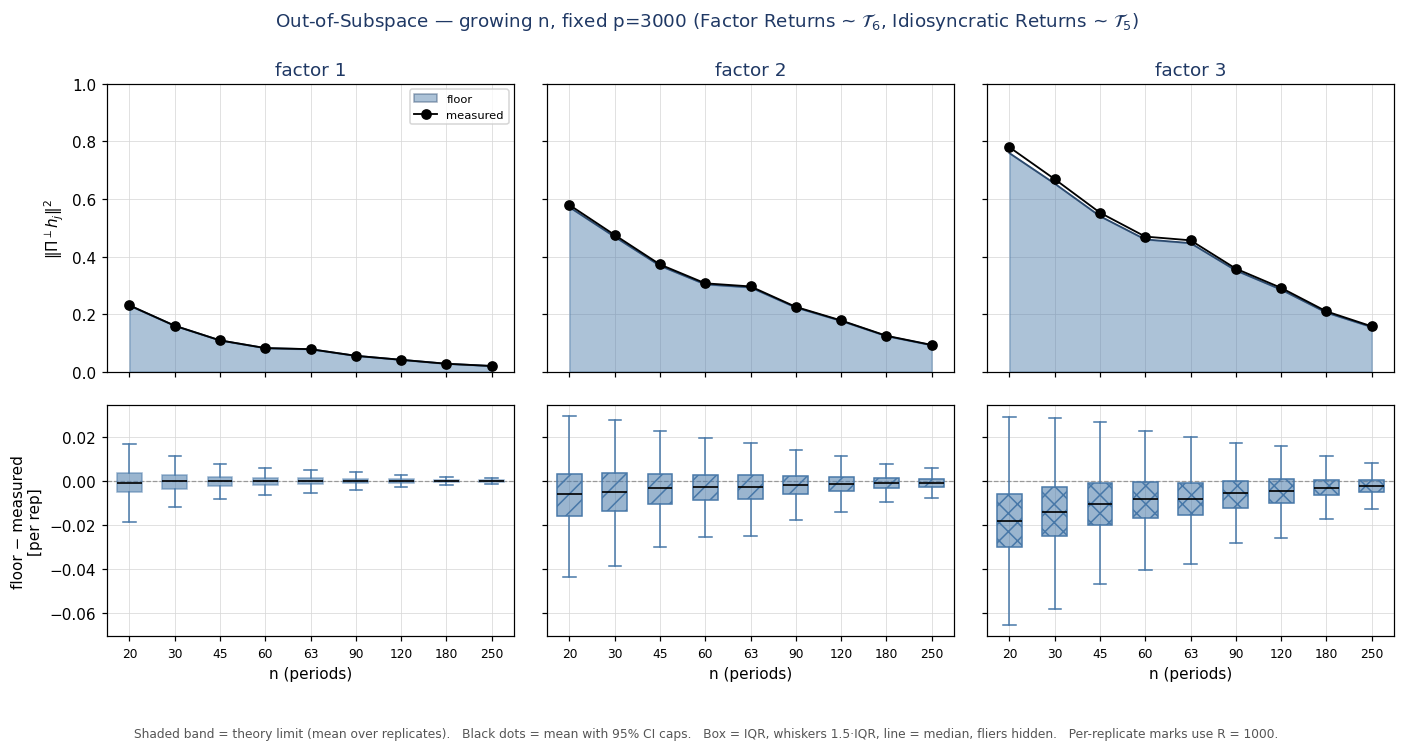

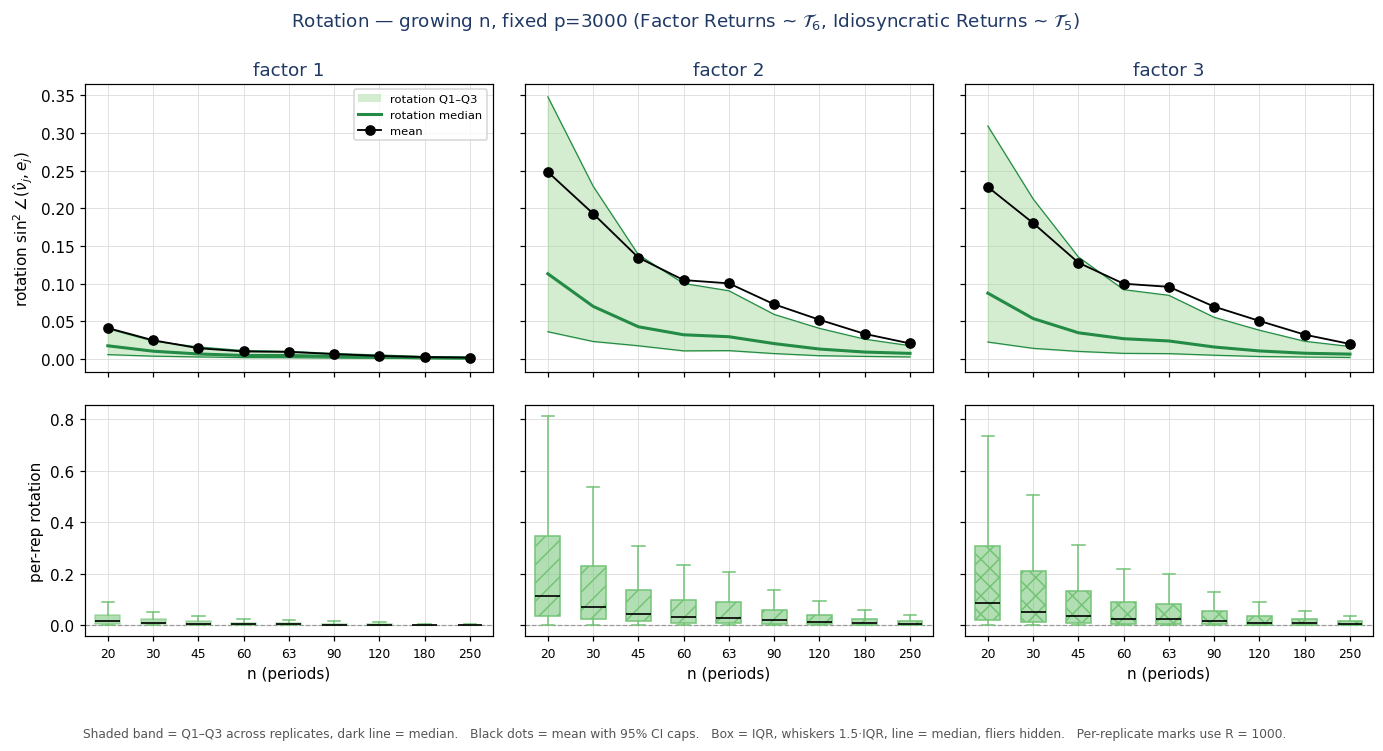

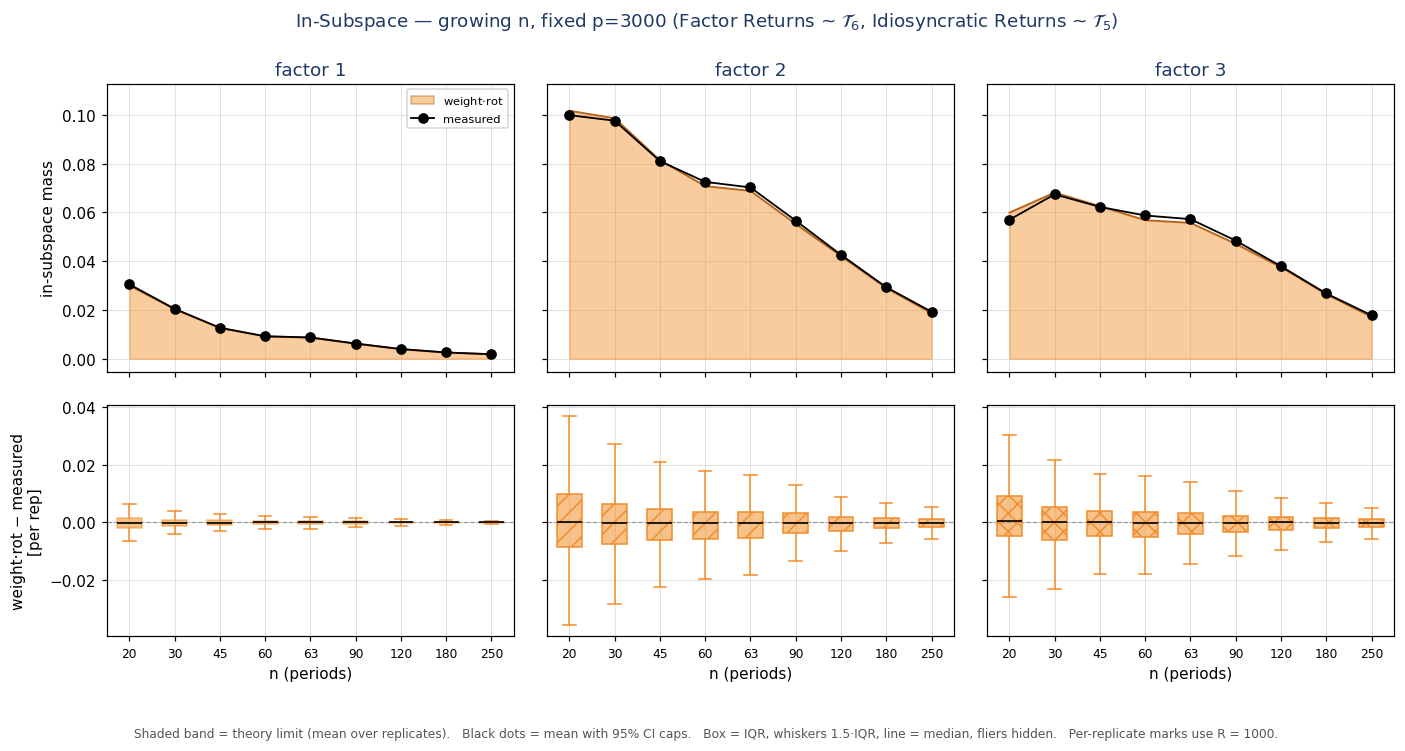

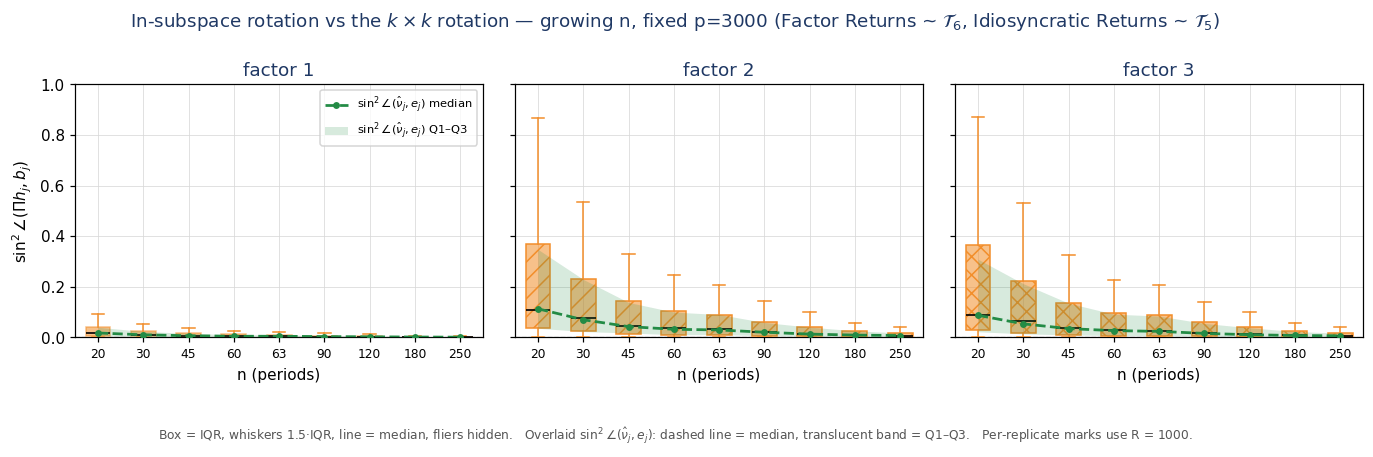

In [ ]:
def comp_theme(color, cmap="Blues"):
    return Theme(factor_colors=(color,) * 6, factor_cmaps=(cmap,) * 6,
                 factor_hatches=FACTOR_HATCHES,
                 ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))

TOTAL_T = comp_theme("black")#comp_theme("#8c8c8c")
OOS_T = comp_theme("#4878a8")
ROT_T = comp_theme("#74c476", "Greens")
INSUB_T = comp_theme("#f28e2b", "Oranges")
ROT_FILL, ROT_LINE = "#a1d99b", "#238b45"

for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="gap [per rep]")],
        theme=TOTAL_T, #suptitle=rf"Total — {lab} {_TAILS}",
        caption=False,
        formats=FIG_FORMATS, out_path=out(f"comp1_total_{key}_qcolor",save=True))
    show(fig)
    #### COMBINED PLOT
    fig, _ = grid(d, key,
        rows=[Row([Band("floor", label="floor"),
                   MeanCI("measured_out_of_subspace", label="measured")], ylim=(0,1),
                  ylabel=r"$\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_oos"), ylabel="floor − measured\n[per rep]")],
        theme=OOS_T, suptitle=rf"Out-of-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp2_oos_{key}_qcolor"))
    show(fig)

    #### ROTATION PLOT
    fig, _ = grid(d, key,
        rows=[Row([QuantileBand("rotation", label="rotation", fill=ROT_FILL, line=ROT_LINE),
                   MeanCI("rotation", label="mean")],
                  ylabel=r"rotation $\sin^2\angle(\hat\nu_j, e_j)$", height=1.0),
              Row(BoxDist("rotation"), ylabel="per-rep rotation")],
        theme=ROT_T, suptitle=rf"Rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp3_rotation_{key}_qcolor"))
    show(fig)

    #### IN-SUBSPACE PLOT
    fig, _ = grid(d, key,
        rows=[Row([Band("theory_insub", label=r"weight$\cdot$rot",
                        fill=THEME.insub_fill, line=THEME.insub_line),
                   MeanCI("measured_in_subspace", label="measured")],
                  ylabel=r"in-subspace mass", height=1.0),
              Row(BoxDist("diff_insub"), ylabel="weight·rot − measured\n[per rep]")],
        theme=INSUB_T, suptitle=rf"In-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp4_insub_{key}_qcolor"))
    show(fig)

    ##### IN-SUBSPACE ROTATION PLOT
    fig, _ = grid(d, key,
        rows=[Row([BoxDist("sin2_in"),
                   RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$",
                              color=ROT_LINE)],
                  ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
        sharey=True, theme=INSUB_T,
        suptitle=rf"In-subspace rotation vs the $k\times k$ rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_insub_rotation_{key}_qcolor"))
    show(fig)

---
## Change log

- **2026-08-13**: modern-API remake of the mono ex-2 v2 figure set — every figure composed
  from `fl_plot` marks (`BandStack`/`Band`/`MeanCI`/`QuantileBand`/`BoxDist`/`RefOverlay`),
  mono + component-colored sections, captions auto-assembled. Composition-only: data from
  the shared ex2v2 cache.